# Digital Signals Theory

In [1]:
%matplotlib inline

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import soundfile as sf

# Chapter 12: Analyzing IIR filters

> ...(Infinite impulse response) filters can be both more powerful and more efficient than FIR (convolutional) filters. However, these benefits come with a cost: IIR filters cannot be analyzed _directly_ by the discrete Fourier transform.

## 12.1. The z-transform

> ... can we analyze IIR filters in the frequency domain as well?
> It turns out that the answer is yes, but **not** with the discrete Fourier transform. We’ll need a new tool, which is known as the _z-transform..._

### 12.1.1. Why can’t we use the DFT?

The DFT is defined in terms of a _finite_ number of analysis frequencies: those which complete an integral number of cycles over a fixed duration of time ($N$ samples).

Consider the case of an IIR filter, such as the exponential moving average we saw earlier as

\begin{flalign}
\qquad {\color{#984ea3}y[n]} &= {\color{#e41a1c}\frac{1}{2}} \cdot {\color{#377eb8}x[n]} + {\color{#4daf4a}\frac{1}{2}} \cdot {\color{#984ea3}y[n-1]} & \text{(11.1)}  \\
\end{flalign}

Its impulse response can be infinite in length: there is no finite $N$ for which all $y[n > 0] = 0$, and so we cannot even begin to construct a DFT.

### 12.1.2. Defining the z-transform

We start with the definition of the Discrete Fourier Transform for a frequency index $m$:

\begin{flalign}
\qquad X[m] &= \sum_{n=0}^{{\color{#377eb8}N-1}} x[n] \cdot e^{-j \cdot 2\pi \cdot \frac{m}{{\color{#377eb8}N}} \cdot n} & \\
\end{flalign}

Note that ${\color{#377eb8}N}$ appears in two places: a) in the limit of the summation; and b) in the denominator in the complex exponential. This is the key limitation of the DFT that prevents us from applying it in the case of IIR, so let's see about removing this limitation.

##### _Leverage the exponent multiplication rule_

Recall that with exponents, powers can be represented as multiplication and vice-versa.

\begin{flalign}
\qquad e^{a \cdot b} &= \left( e^a \right)^b & \\
\end{flalign}

So in factoring out that $-n$ in the complex exponential bit, we can rewrite that as:

\begin{flalign}
\qquad e^{-j \cdot 2\pi \cdot \frac{m}{N} \cdot n} &= \left( e^{j \cdot 2\pi \cdot \frac{m}{N}} \right)^{-n} & \\
\end{flalign}

And now we can re-interpret the complex exponential bit as a sequence, _parameterized by sample index $n$_, and _generated by a complex number $z_{m/N}$ on the unit circle at the angle $\theta = 2\pi \cdot \frac{m}{N}$._

\begin{flalign}
\qquad z_{m/N} &= e^{j \cdot 2\pi \cdot \frac{m}{N}} & \text{(12.1)} \\
\end{flalign}


* $\frac{m}{N}$ is the fraction of the unit circle we travel in each step $n$ of this sequence. In the image below, $\theta = \frac{2\pi}{8}$. The complex number $z_{1/8} = e^{j \cdot 2pi \cdot \frac{1}{8}}$ is raised to successive powers for $n = 0, -1, -2, -3, \ldots$. The result is a clockwise movement from ${z_{1/8}}^0$ going around in steps of $\frac{2\pi}{8}$ radians.

![McFee's Digital Signals Theory, Ch. 12, Figure 12.1](bin/dstbook_fig_12.1.png)


* So, we can transform the DFT summation up to a finite $N-1$ to another summation, but this one going up to infinity!

\begin{flalign}
\qquad X[m] &= \sum_{n=0}^{{\color{#377eb8}N-1}} x[n] \cdot e^{-j \cdot 2\pi \cdot \frac{m}{{\color{#377eb8}N}} \cdot n} & \\\\
\qquad      &= \sum_{n=0}^{\infty} x[n] \cdot \left( z_{m/N} \right)^{-n} & \\\\
\end{flalign}

where we <span style="background-color:#3FF;">_assume silence after ${\color{#377eb8}N}$ samples instead of just pure, infinite repetition._</span>

##### Definition 12.1 (The z-transform)

> Given a sequence ${\color{#377eb8}x[n]}$ (of possibly infinite length), the z-transform is a function $X(z)$ over complex numbers $z$ defined as follows:
>
> \begin{flalign}
\qquad X(z) &= \sum_{n=0}^{\infty} x[n] \cdot z^{-n} & \text{(12.2)} \\
\end{flalign}

### 12.1.3. Relating the z-transform to the DFT

* Unlike the DFT, the z-transform does not produce a finite sequence of coefficients.
* Instead, it produces a function that can be evaluated for any complex number $z$.
* So the DFT can be recovered from the z-transform by evaluating $X(z)$ at carefully chosen points $z$.
* The DFT coefficients $X[m]$ can be extracted from the _z-transform_ as follows:

\begin{flalign}
\qquad X[m] &= X \left( e^{j \cdot 2\pi \cdot \frac{m}{N}} \right) & \\\\
\end{flalign}

### 12.1.4. Aside: continuous frequency and the DTFT

* The _Discrete-time Fourier Transform_ (DTF) is a special case of the _z-transform._
* The DFT uses ${\color{#377eb8}N}$ analysis frequences $0, \frac{f_s}{{\color{#377eb8}N}}, \frac{2 \cdot f_s}{{\color{#377eb8}N}}, \frac{3 \cdot f_s}{{\color{#377eb8}N}}, \ldots$
* In contrast, the DTFT is defined for **any** frequency $f$, and not just only analysis frequencies.
* The DTFT for any frequency $f$ is obtained by evaluating the _z-transform_ at a point on the unit-circle with angle $\theta = \frac{2\pi \cdot f}{f_s}$:

\begin{flalign}
\qquad DTFT(x)(f) &= X \left( e^{j \cdot 2\pi \cdot \frac{f}{f_s}} \right) & \\\\
\end{flalign}

* And so the DTFT makes the connection between _frequency_ and _angle_ precisely: frequency $f$ with sampling frequency $f_s$ is mapped to a complex number with _unit magnitude_ and _angle_ $\theta = \frac{2\pi \cdot f}{f_s}$.
* <span style="background-color:#3FF;">Aliasing frequencies map to the same angle, as:</span>

\begin{flalign}
\qquad 2\pi \cdot \frac{f + {\color{#cb181d}k \cdot f_s}}{f_s} &= 2\pi \cdot \frac{f}{f_S} + 2\pi \cdot {\color{#cb181d}k} & \\\\
\qquad                                                         &= 2\pi \cdot \frac{f}{f_S}  & \\\\
\end{flalign}

* <span style="background-color:#3FF;">The Nyquist frequency $f = \frac{f_s}{2}$ is mapped to angle $2\pi \cdot \frac{f_s/2}{f_s} = \pi \equiv -\pi$</span>
* In the DTFT, the analysis frequencies of the DFT are generalized using $f = m \cdot \frac{f_s}{N}$, which recovers the $z_{m/N}$ explained earlier.
* Furthermore, the range of frequencies $0 \leq f \leq f_s$  are mapped continuously to the range of angles $0 \leq \theta \leq 2\pi$
. 

## 12.2. Properties of the _z-transform_

### 12.2.1. Linearity

##### Theorem 12.1 (The _z-Transform is linear_)

> Let $y[n] = {\color{#984ea3}c_1} \cdot {\color{#377eb8}x_1[n]}  + {\color{#984ea3}c_2} \cdot {\color{#377eb8}x_2[n]}$
> be a combination of two signals ${\color{#377eb8}x_1[n]}$ and ${\color{#377eb8}x_2[n]}$, each with gain coefficients
> ${\color{#984ea3}c_1, c_2} \in \mathbb{R}$.
> <p/>
> The <i>z-transform</i> of $y[n]$ is equivalent to:
> \begin{flalign}
\qquad Y(z) &= {\color{#984ea3}c_1} \cdot {\color{#377eb8}X_1(z)}  + {\color{#984ea3}c_2} \cdot {\color{#377eb8}X_2(z)}  & \\
\end{flalign}
> where ${\color{#377eb8}X_1(z), X_2(z)}$ are the <i>z-transforms</i> of ${\color{#377eb8}x_1[n]}$ and ${\color{#377eb8}x_2[n]}$ respectively.


##### _i.e., the z-Transform of a weighted combination of signals is equivalent to the weighted combination of their individual z-Transforms._


### 12.2.2. Shifting theorem

##### Theorem 12.2 (_z-Transform shifting theorem_)

> Let $y[n] = {\color{#377eb8}x[n -} {\color{#e41a1c}k}{\color{#377eb8}]}$ be a ${\color{#e41a1c}k}$-step delay of signal ${\color{#377eb8}x[n]}$,
> under the assumption that ${\color{#377eb8}x[n<0]} = 0$.
> <p/>
> The <i>z-transform</i> of $y[n]$ is given by:
> \begin{flalign}
\qquad Y(z) &= {\color{#e41a1c}z^{-k}} \cdot {\color{#377eb8}X(z)} & \text{(12.3)} \\
\end{flalign}

As explained earlier in 12.1.3, the DFT can be derived from the _z-transform_ by using $z = e^{2\pi \cdot j \cdot \frac{m}{N}}$. Plug this into the z-transform shifting theorem equation (12.3), we see that a delay ${\color{#e41a1c}k}$ results in multiplication by ${\color{#e41a1c}z^{-k}}$, which yields:

\begin{flalign}
\qquad \left( e^{j \cdot 2\pi \cdot \frac{m}{N}} \right)^{{\color{#e41a1c}-k}} &= e^{- j \cdot 2\pi \cdot {\color{#e41a1c}k} \cdot \frac{m}{N}} & \\\\
\end{flalign}

which is as <span style="background-color:#3FF;">_exactly expected from the DFT shifting theorem._</span>

### 12.2.3. Convolution theorem

##### Theorem 12.3 (z-Transform convolution theorem)

> Let 
> \begin{flalign}
\qquad y[n] &= \sum_{k=0}^{K-1} {\color{#e41a1c}h[k]} \cdot {\color{#377eb8}x[n-k]} & \\
\end{flalign}
> be the convolution of a signal ${\color{#377eb8}x[n]}$ with an impulse response ${\color{#e41a1c}h[k]}$ of length $K$.
> Assume ${\color{#e41a1c}h[k<0] = h[k \geq K] = 0}$.
> <p/>
> The <i>z-transform</i> of $y$ is equal to the product of the <i>z-transforms</i>:
> \begin{flalign}
\qquad Y(z) &= {\color{#e41a1c}H(z)} \cdot {\color{#377eb8}X(z)} & \text{(12.4)} \\
\end{flalign}
> where $Y(z)$, ${\color{#e41a1c}H(z)}$ and ${\color{#377eb8}X(z)}$ are the respective <i>z-transforms</i> of $y[n]$, ${\color{#e41a1c}h[k]}$, and ${\color{#377eb8}x[n]}$ 

## 12.3. Transfer functions
 
* In the Finite Impulse Response case, we used the _Discrete Fourier Transform_ ${\color{#e41a1c}H[m]}$ of the impulse response ${\color{#e41a1c}h[k]}$ to see how a filter may delay and gain/attenuate different frequencies in the _frequency domain_.
* For Infinite Impulse Response situations, we cannot use the _DFT_ directly as we do for FIR, _but we can do similar analyses from the viewpoint of the z-transform_.
* This is possible by applying the above ideas and intuitions to derive something similar to ${\color{#e41a1c}H[m]}$ known as the **_transfer function_**.

### 12.3.1. Defining a transfer function

##### Definition 12.2 (transfer function)

> Let ${\color{#4daf4a}a}$ and ${\color{#e41a1c}b}$ be the feed-back and feed-forward coefficients of a linear IIR filter.
> \begin{flalign}
\qquad {\color{#4daf4a}a[0]} \cdot y[n] &= \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot {\color{#377eb8}x[n-k]} - \sum_{k=1}^{K-1} {\color{#4daf4a}a[k]} \cdot y[n-k] & \\
\end{flalign}
> <p/>
> The <i><b>transfer function</b></i> of this filter is defined as:
> \begin{flalign}
\qquad {\color{#e41a1c}H(z)} &= \frac{{\color{#e41a1c}B(z)}}{{\color{#4daf4a}A(z)}} & \\\\
\qquad                       &= \frac{ \sum_{k=0}^{K-1} {\color{#e41a1c}b[k]} \cdot z^{-k} }{ \sum_{k=0}^{K-1} {\color{#4daf4a}a[k]} \cdot z^{-k} } & \text{(12.7)} \\
\end{flalign}

### 12.3.2. Using transfer functions

**_Transfer functions_** give us a generalization of the convolution theorem that works in the case of feedback filters.


\begin{flalign}
\qquad Y(z) &= {\color{#e41a1c}H(z)} \cdot {\color{#377eb8}X(z)} &  \\\\
\qquad      &= \frac{{\color{#e41a1c}B(z)}}{{\color{#4daf4a}A(z)}} \cdot {\color{#377eb8}X(z)} & \text{(12.8)} \\
\end{flalign}

* In the special case ${\color{#4daf4a}a = [1]}$ (i.e., there is _no_ feedback in the filter),

\begin{flalign}
\qquad A(z) &= \sum_{k=0}^{\infty} {\color{#4daf4a}a[k]} \cdot z^{-k} &  \\\\
\qquad      &= {\color{#4daf4a}a[0]} \cdot z^{0} &  \\\\
\qquad      &= {\color{#4daf4a}a[0]} &  \\\\
\qquad      &= 1 &  \\
\end{flalign}

* Subsequently, the _transfer function_ simplifies to recover the convolution theorem.:

\begin{flalign}
\qquad {\color{#e41a1c}H(z)} &= \frac{{\color{#e41a1c}B(z)}}{1} & \\\\
\qquad                       &= {\color{#e41a1c}B(z)} \\
\end{flalign} 

* Evaluating ${\color{#e41a1c}H(z)}$ at values of $z$ with unit magnitude — i.e., $z = e^{j \cdot \theta}$ — produces the _frequency response of the filter._
* c.f. [`scipy.signal.freqz`](https://docs.scipy.org/doc/scipy-1.16.0/reference/generated/scipy.signal.freqz.html#freqz)

#### 12.3.2.1. Example: analyzing a Butterworth filter

In [2]:
fs = 44100  # 44.1K sampling rate
fc = 500    # 500 Hz cutoff frequency
order = 10  # order-10 filter

b, a = sp.signal.butter(order, fc, fs=fs)

freq, H = sp.signal.freqz(b, a, fs=fs)

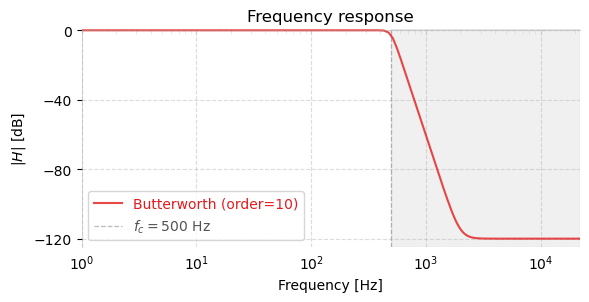

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))

ax.grid(linestyle='--', alpha=0.4, color='#A9A9A9')
# Eliminate upper and right axes
ax.spines['right'].set_color('none')
ax.spines['top'].set_color('none')
ax.spines['left'].set(color='#A9A9A9', alpha=0.4)
ax.spines['bottom'].set(position='zero', color='#A9A9A9', alpha=0.4)

ax.semilogx(freq, 20 * np.log10(np.abs(H) + 1e-6), label='Butterworth (order=10)', color='#e41a1c', alpha=0.8)
ax.axvline(fc, zorder=-1, label=r'$f_c = 500$ Hz', linewidth=0.9, color='#525252', linestyle='--', alpha=0.4)
ax.axvspan(fc, fs/2, color='#737373', alpha=0.1, zorder=-1)

ax.legend(loc='upper right')
ax.set(xlabel='Frequency [Hz]', ylabel='$|H|$ [dB]', title='Frequency response');
ax.set(yticks=[0, -40, -80, -120], ylim=[-125., 0.5], xlim=[1., fs/2])#, xticks=[1e-1, fc, fs /2], xlim=[1e-1, fs/2], xticklabels=[0, r'$f_c$', 'Nyquist'])
ax.tick_params(axis='x', which=u'both', length=3, pad=158, color='#A9A9A940')

ax.label_outer()
ax.legend(loc='lower left', labelcolor='linecolor')

fig.tight_layout()
plt.show()